In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/nifty50_labeled.csv", index_col=0, parse_dates=True)

FEATURE_COLS = [
    "Return", "Volatility_10",
    "SMA_10", "SMA_20", "SMA_50",
    "EMA_10", "EMA_20", "EMA_50",
    "RSI_14", "MACD", "MACD_Signal",
    "BB_Upper", "BB_Lower", "BB_Middle", "BB_Width",
    "ATR_14", "Momentum_10",
]
LABEL_MAP = {0: "DOWN", 1: "NEUTRAL", 2: "UP"}

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
df.head()

Shape: (2658, 24)
Date range: 2015-03-17 to 2025-12-30


,Close,High,Low,Open,Volume,Return,Volatility_10,SMA_10,SMA_20,SMA_50,...,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Middle,BB_Width,ATR_14,Momentum_10,Next_Return,Target
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-17,8723.299805,8742.549805,8630.799805,8689.099609,177000,0.010442,0.009786,8780.560059,8799.122412,8669.166973,...,9.512065,41.779465,9009.020946,8589.223879,8799.122412,0.047709,119.194705,-233.450195,-0.004287,0
2015-03-18,8685.900391,8747.250000,8664.000000,8742.900391,156400,-0.004287,0.009476,8749.525098,8792.949951,8674.975977,...,3.776064,34.178785,9008.759452,8577.140450,8792.949951,0.049087,116.627226,-310.349609,-0.005900,0
2015-03-19,8634.650391,8788.200195,8614.650391,8749.450195,163500,-0.005900,0.009377,8720.725098,8781.227490,8680.100977,...,-4.849305,26.373167,9004.945794,8557.509187,8781.227490,0.050954,120.693125,-288.000000,-0.007383,0
2015-03-20,8570.900391,8627.900391,8553.000000,8627.900391,174600,-0.007383,0.009286,8684.040137,8765.007520,8688.971982,...,-16.637280,17.771077,9000.625486,8529.389553,8765.007520,0.053763,117.904358,-366.849609,-0.002333,1
2015-03-23,8550.900391,8608.349609,8540.549805,8591.549805,150700,-0.002333,0.007361,8663.455176,8750.872559,8697.947988,...,-27.278716,8.761119,9002.537005,8499.208112,8750.872559,0.057518,114.325462,-205.849609,-0.000930,1


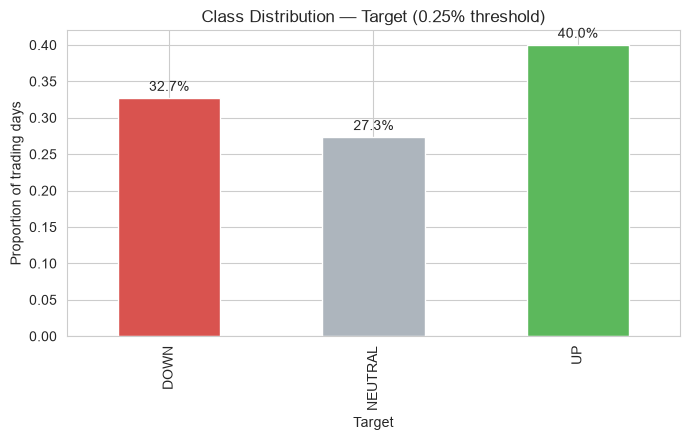

Target
DOWN       0.327
NEUTRAL    0.273
UP         0.400
Name: proportion, dtype: float64

In [2]:
counts = df["Target"].value_counts(normalize=True).sort_index()
counts.index = counts.index.map(LABEL_MAP)
counts = counts.reindex(["DOWN", "NEUTRAL", "UP"])

ax = counts.plot(kind="bar", color=["#d9534f", "#adb5bd", "#5cb85c"], figsize=(7, 4.5))
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")
ax.set_title("Class Distribution — Target (0.25% threshold)")
ax.set_ylabel("Proportion of trading days")
plt.tight_layout()
plt.show()

counts.round(3)

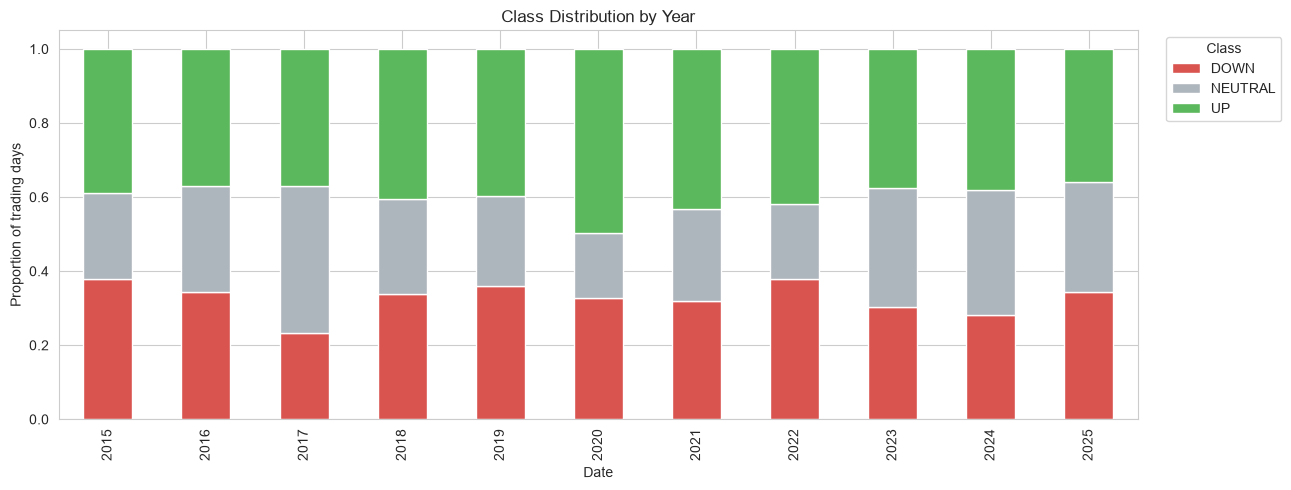

Target,DOWN,NEUTRAL,UP
Date,,,
2015,0.379,0.231,0.390
2016,0.344,0.287,0.369
2017,0.234,0.395,0.371
2018,0.339,0.257,0.404
2019,0.361,0.241,0.398
2020,0.328,0.176,0.496
2021,0.319,0.250,0.431
2022,0.379,0.202,0.419
2023,0.302,0.322,0.376


In [3]:
yearly = (
    df.groupby(df.index.year)["Target"]
    .value_counts(normalize=True)
    .unstack()
    .rename(columns=LABEL_MAP)
    .reindex(columns=["DOWN", "NEUTRAL", "UP"])
)

ax = yearly.plot(kind="bar", stacked=True, color=["#d9534f", "#adb5bd", "#5cb85c"], figsize=(13, 5))
ax.set_title("Class Distribution by Year")
ax.set_ylabel("Proportion of trading days")
ax.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
yearly.round(3)

In [4]:
from validation import get_walk_forward_folds, get_test_split

print("=== Walk-Forward Folds ===")
folds = get_walk_forward_folds(df)

print("\n=== Final Test Split ===")
train_final, test_final = get_test_split(df)

=== Walk-Forward Folds ===
Fold 1 | Train: 2015-01-01 to 2019-12-31 (1173 rows) | Val: 2020-01-01 to 2020-12-31 (250 rows)
Fold 2 | Train: 2015-01-01 to 2020-12-31 (1423 rows) | Val: 2021-01-01 to 2021-12-31 (248 rows)
Fold 3 | Train: 2015-01-01 to 2021-12-31 (1671 rows) | Val: 2022-01-01 to 2022-12-31 (248 rows)
Fold 4 | Train: 2015-01-01 to 2022-12-31 (1919 rows) | Val: 2023-01-01 to 2023-12-31 (245 rows)

=== Final Test Split ===

Final Test | Train: 2015-01-01 to 2023-12-31 (2164 rows) | Test: 2024-01-01 to present (494 rows)


In [5]:
fold_summary = []
for f in folds:
    val_counts = f["val"]["Target"].value_counts(normalize=True).reindex([0,1,2]).rename(LABEL_MAP)
    fold_summary.append({"fold": f["fold"], **val_counts.to_dict()})
pd.DataFrame(fold_summary).set_index("fold").round(3)

,DOWN,NEUTRAL,UP
fold,,,
1,0.328,0.176,0.496
2,0.319,0.250,0.431
3,0.379,0.202,0.419
4,0.302,0.322,0.376


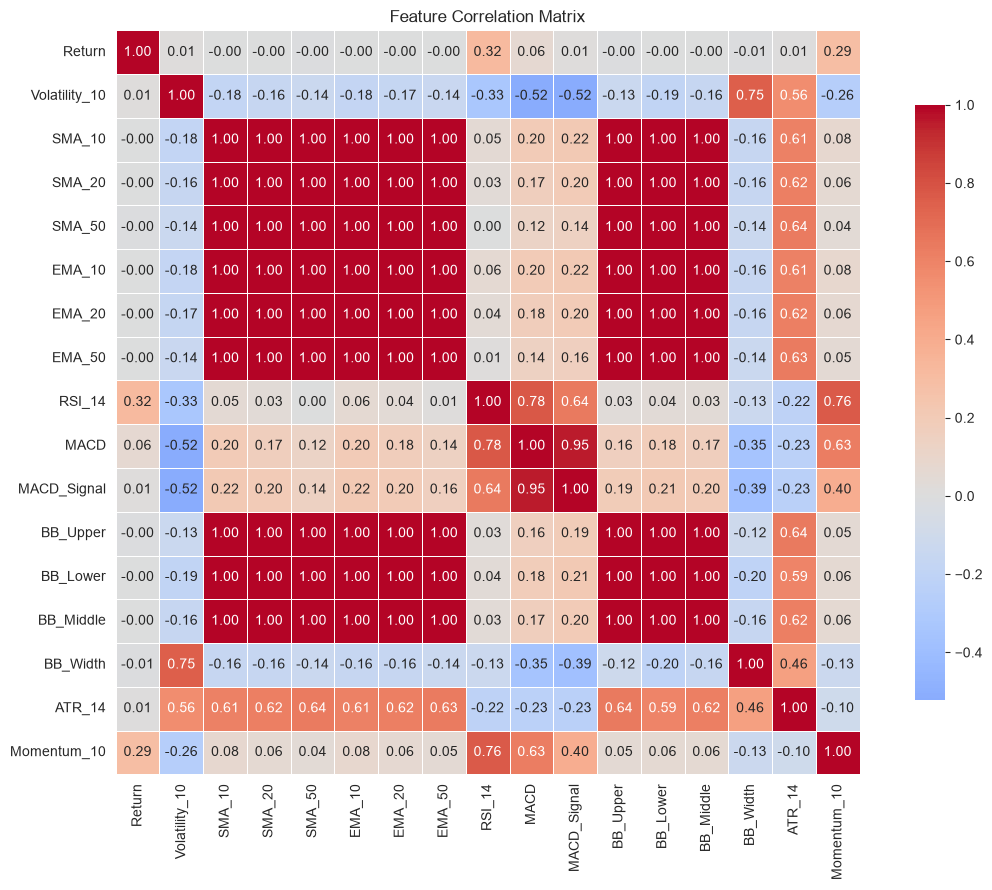

In [6]:
corr = df[FEATURE_COLS].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "correlation"]
high_corr = pairs[pairs["correlation"].abs() > 0.85].sort_values("correlation", key=abs, ascending=False)
print(f"{len(high_corr)} feature pairs with |correlation| > 0.85:")
high_corr

37 feature pairs with |correlation| > 0.85:


,feature_1,feature_2,correlation
64,SMA_20,BB_Middle,1.000000
39,SMA_10,EMA_10,0.999949
57,SMA_20,EMA_20,0.999908
115,EMA_20,BB_Middle,0.999908
91,EMA_10,EMA_20,0.999754
75,SMA_50,EMA_50,0.999740
40,SMA_10,EMA_20,0.999712
56,SMA_20,EMA_10,0.999521
98,EMA_10,BB_Middle,0.999521
37,SMA_10,SMA_20,0.999505


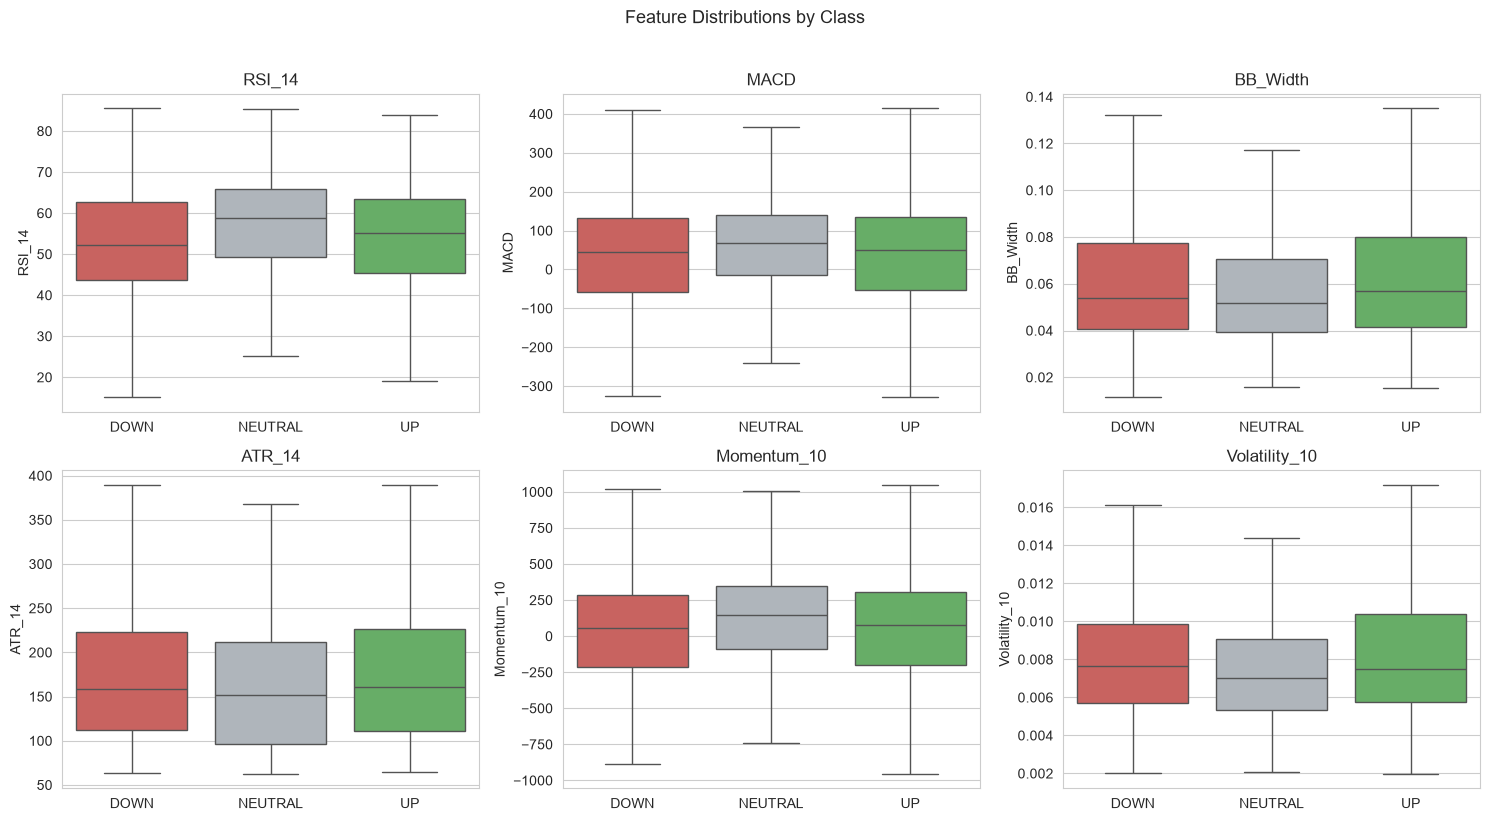

In [15]:
plot_df = df.dropna(subset=FEATURE_COLS + ["Target"]).copy()
plot_df["label"] = plot_df["Target"].map(LABEL_MAP)

key_features = ["RSI_14", "MACD", "BB_Width", "ATR_14", "Momentum_10", "Volatility_10"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=plot_df, x="label", y=feat, order=["DOWN", "NEUTRAL", "UP"],
                hue="label", legend=False,
                ax=ax, palette=["#d9534f", "#adb5bd", "#5cb85c"], showfliers=False)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Feature Distributions by Class", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

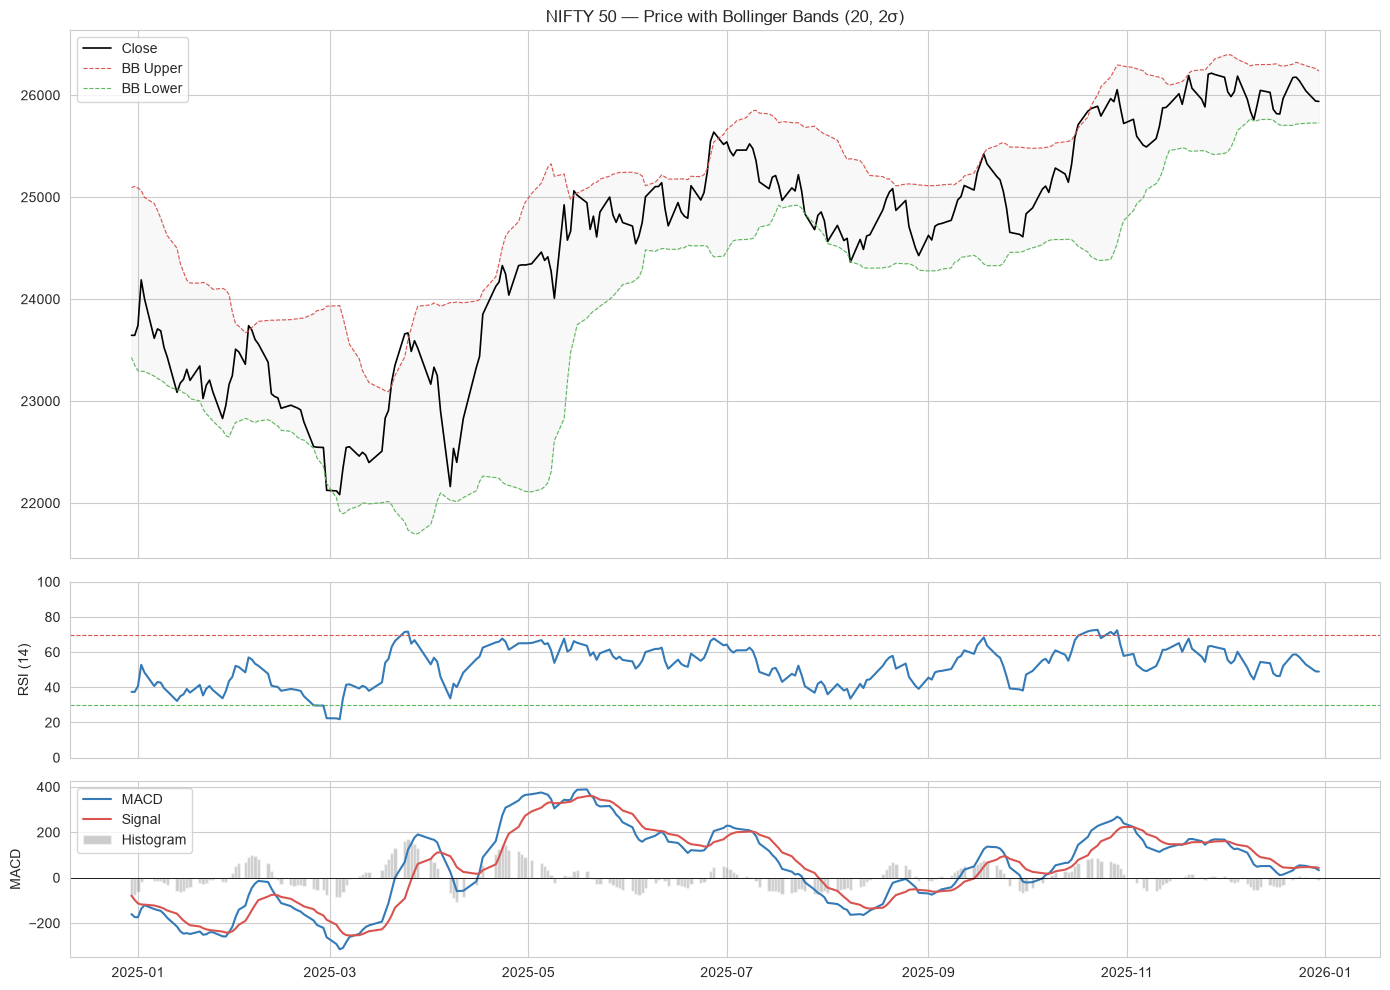

In [9]:
window = df.tail(250).copy()
window["MACD_Hist"] = window["MACD"] - window["MACD_Signal"]

fig, (ax_price, ax_rsi, ax_macd) = plt.subplots(
    3, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]}
)

ax_price.plot(window.index, window["Close"], label="Close", color="black", linewidth=1.2)
ax_price.plot(window.index, window["BB_Upper"], label="BB Upper", color="#d9534f", linestyle="--", linewidth=0.8)
ax_price.plot(window.index, window["BB_Lower"], label="BB Lower", color="#5cb85c", linestyle="--", linewidth=0.8)
ax_price.fill_between(window.index, window["BB_Lower"], window["BB_Upper"], alpha=0.05, color="grey")
ax_price.set_title("NIFTY 50 — Price with Bollinger Bands (20, 2σ)")
ax_price.legend(loc="upper left")

ax_rsi.plot(window.index, window["RSI_14"], color="#337ab7")
ax_rsi.axhline(70, color="#d9534f", linestyle="--", linewidth=0.8)
ax_rsi.axhline(30, color="#5cb85c", linestyle="--", linewidth=0.8)
ax_rsi.set_ylabel("RSI (14)")
ax_rsi.set_ylim(0, 100)

ax_macd.plot(window.index, window["MACD"], label="MACD", color="#337ab7")
ax_macd.plot(window.index, window["MACD_Signal"], label="Signal", color="#d9534f")
ax_macd.bar(window.index, window["MACD_Hist"], label="Histogram", color="grey", alpha=0.4, width=1.0)
ax_macd.axhline(0, color="black", linewidth=0.6)
ax_macd.set_ylabel("MACD")
ax_macd.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [10]:
na_counts = df[FEATURE_COLS + ["Target"]].isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print("Columns with missing values:")
na_counts if len(na_counts) else print("None -- clean.")

Columns with missing values:
None -- clean.


In [11]:
vix_raw = pd.read_csv("../data/raw/india_vix_raw.csv", skiprows=[1, 2])
vix_raw = vix_raw.rename(columns={"Price": "Date"})
vix_raw["Date"] = pd.to_datetime(vix_raw["Date"])
vix_raw = vix_raw.set_index("Date")

usdinr_raw = pd.read_csv("../data/raw/usdinr_raw.csv", skiprows=[1, 2])
usdinr_raw = usdinr_raw.rename(columns={"Price": "Date"})
usdinr_raw["Date"] = pd.to_datetime(usdinr_raw["Date"])
usdinr_raw = usdinr_raw.set_index("Date")

print(vix_raw.shape, vix_raw.columns.tolist())
vix_raw.head()

(2698, 5) ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,15.030000,15.510000,14.76,15.12,0
2015-01-02,13.800000,15.030000,13.48,15.03,0
2015-01-05,14.150000,14.410000,13.15,13.80,0
2015-01-06,17.420000,17.870001,13.46,14.15,0
2015-01-07,18.139999,19.070000,16.50,17.42,0


In [12]:
import os
print(os.listdir("../data/raw"))

['.gitkeep', 'india_vix_raw.csv', 'nifty50_raw.csv', 'usdinr_raw.csv']


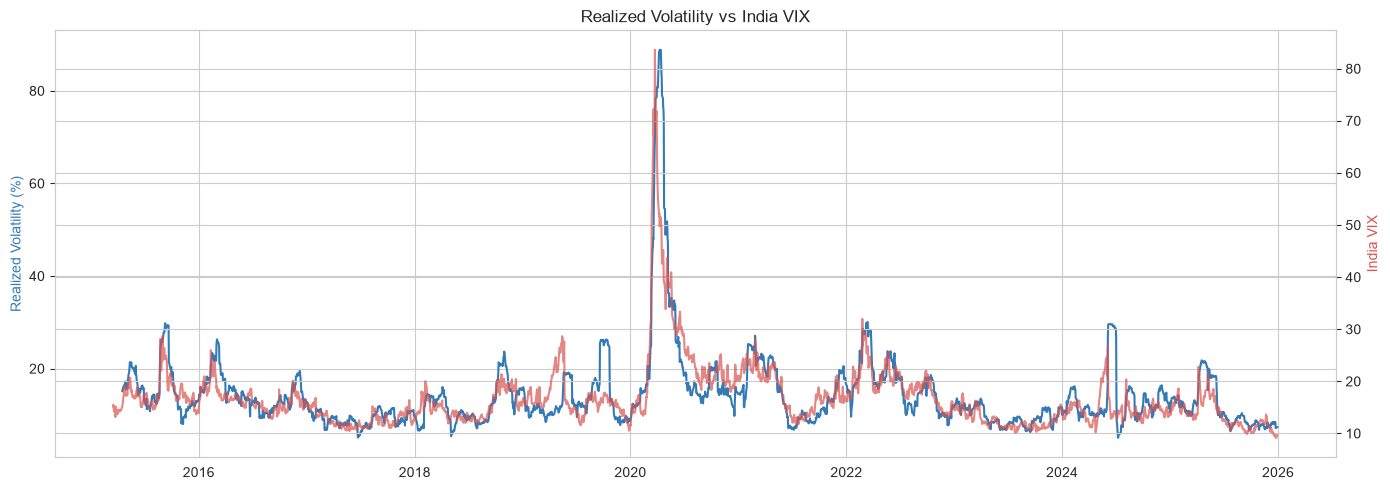

Correlation (20d realized vol vs VIX): 0.836


In [13]:
macro = df[["Close", "Return"]].join(vix_raw[["Close"]].rename(columns={"Close": "VIX_Close"}), how="left")
macro = macro.join(usdinr_raw[["Close"]].rename(columns={"Close": "USDINR_Close"}), how="left")
macro[["VIX_Close", "USDINR_Close"]] = macro[["VIX_Close", "USDINR_Close"]].ffill()
macro["realized_vol_20d"] = macro["Return"].rolling(20).std() * np.sqrt(252) * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(macro.index, macro["realized_vol_20d"], label="20d Realized Volatility (annualized %)", color="#337ab7")
ax1.set_ylabel("Realized Volatility (%)", color="#337ab7")
ax2 = ax1.twinx()
ax2.plot(macro.index, macro["VIX_Close"], label="India VIX", color="#d9534f", alpha=0.7)
ax2.set_ylabel("India VIX", color="#d9534f")
plt.title("Realized Volatility vs India VIX")
fig.tight_layout()
plt.show()

corr_val = macro[["realized_vol_20d", "VIX_Close"]].dropna().corr().iloc[0, 1]
print(f"Correlation (20d realized vol vs VIX): {corr_val:.3f}")

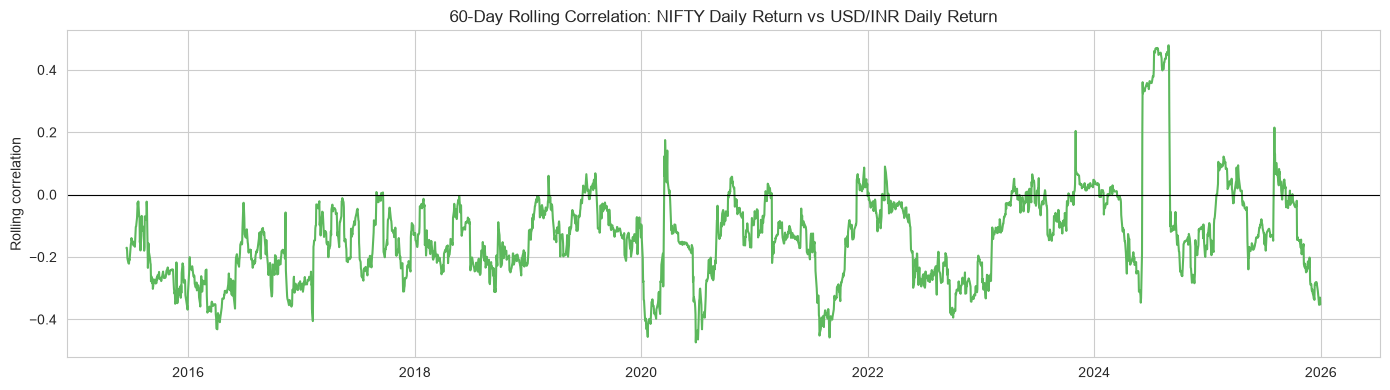

Full-period correlation: -0.148


In [14]:
rolling_corr = macro["Return"].rolling(60).corr(macro["USDINR_Close"].pct_change())

plt.figure(figsize=(14, 4))
plt.plot(macro.index, rolling_corr, color="#5cb85c")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("60-Day Rolling Correlation: NIFTY Daily Return vs USD/INR Daily Return")
plt.ylabel("Rolling correlation")
plt.tight_layout()
plt.show()

print(f"Full-period correlation: {macro['Return'].corr(macro['USDINR_Close'].pct_change()):.3f}")

## Summary of Findings — for the Team

1. **Class balance** — UP 40.0% / DOWN 32.7% / NEUTRAL 27.3% at the frozen 0.25% threshold. No class is a small minority; workable for both classification and backtesting.
2. **2020 is an outlier year** — UP jumps to 49.6% and NEUTRAL drops to 17.6% (COVID recovery rally). Fold 1's validation year (2020) will likely show different metrics than the other folds purely due to this regime shift, not model quality.
3. **Redundant features** — BB_Middle is mathematically identical to SMA_20 (correlation 1.000, by construction). SMA/EMA pairs of the same window and other Bollinger-derived columns are also highly correlated (>0.99). Consider dropping some for the LSTM input specifically.
4. **Feature separating power is weak** — RSI, MACD, BB_Width, ATR, Momentum, and Volatility all show heavily overlapping distributions across DOWN/NEUTRAL/UP. No single technical indicator strongly separates next-day direction on its own — expected and consistent with the project's core research question (does model complexity help capture what simple indicators can't?).
5. **India VIX tracks realized volatility well** — correlation of 0.836 between 20-day realized volatility and VIX, with both spiking sharply together during the 2020 COVID crash. Confirms VIX is a reliable volatility feature.
6. **USD/INR has a weak, unstable relationship with NIFTY** — full-period correlation of -0.148, rolling correlation swings between roughly -0.4 and +0.4 over time. Keep as a feature, but don't expect it to be a strong standalone predictor.
7. **Data quality** — no missing values in `nifty50_labeled.csv` outside expected indicator warm-up rows (already handled upstream by `src/features.py`).

**Next step:** threshold is already frozen at 0.25% (Rule #4 satisfied) — no further action needed there. Flag Fold 1 (2020) results as potentially noisier when interpreting walk-forward results across models.